# 2CSSIQ Lab03. Decision trees (DTs) and Ensemle Learning

<p style='text-align: right;font-style: italic;'>Designed by: Dr. Abdelkrime Aries</p>

In this lab, we will learn all about decision trees and ensemble learning.



**Team:**
- **Member 01**: CHATTAH Salsabila
- **Member 02**: BADAOUI Ikram
- **Group**: SIQ1

In [3]:
import sys, timeit
from collections import OrderedDict
from typing          import Tuple, List, Type, Union
from collections.abc import Callable

sys.version

'3.13.7 (main, Aug 20 2025, 22:17:40) [GCC 14.3.0]'

In [4]:
import numpy             as np
import pandas            as pd 
import matplotlib.pyplot as plt 
import matplotlib
%matplotlib inline

np.__version__, pd.__version__, matplotlib.__version__

('2.3.5', '2.3.3', '3.10.8')

In [5]:
import sklearn

from sklearn.model_selection import train_test_split
# from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.linear_model    import SGDClassifier
# from sklearn.multiclass      import OneVsRestClassifier
# from sklearn.multiclass      import OneVsOneClassifier
from sklearn.metrics         import accuracy_score
# from sklearn.metrics         import classification_report
# from sklearn.metrics         import log_loss

from   sklearn.tree    import DecisionTreeClassifier
from   sklearn.metrics import f1_score
from   sklearn         import tree
from   sklearn.ensemble import RandomForestClassifier

from sklearn.ensemble     import BaggingClassifier
from sklearn.ensemble     import AdaBoostClassifier
from sklearn.ensemble     import StackingClassifier


sklearn.__version__

'1.8.0'

In [6]:
# This code is used to filter warnings concerning convergence
# In general, when the maximum number of iterations is not suffisant to converge
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [7]:
!pip install graphviz
# Also you need to install the graphviz backend in the system
# Lien : https://graphviz.org/download/

## I. Algorithms implementation

In this section, we will try to implement ID3 and CART decision trees. 

In [8]:
# Dataset play 

# outlook & temperature & humidity & windy
Xplay_cat = np.array([
    ['sunny'   , 'hot' , 'high'  , 'no'],
    ['sunny'   , 'hot' , 'high'  , 'yes'],
    ['overcast', 'hot' , 'high'  , 'no'],
    ['rainy'   , 'mild', 'high'  , 'no'],
    ['rainy'   , 'cool', 'normal', 'no'],
    ['rainy'   , 'cool', 'normal', 'yes'],
    ['overcast', 'cool', 'normal', 'yes'],
    ['sunny'   , 'mild', 'high'  , 'no'],
    ['sunny'   , 'cool', 'normal', 'no'],
    ['rainy'   , 'mild', 'normal', 'no'],
    ['sunny'   , 'mild', 'normal', 'yes'],
    ['overcast', 'mild', 'high'  , 'yes'],
    ['overcast', 'hot' , 'normal', 'no'],
    ['rainy'   , 'mild', 'high'  , 'yes']
])

# temperature & humidity & windy
Xplay_num = np.array([
    [30, 85, 0],
    [27, 90, 1],
    [28, 78, 0],
    [21, 96, 0],
    [20, 80, 0],
    [18, 70, 1],
    [18, 65, 1],
    [22, 95, 0],
    [21, 70, 0],
    [24, 80, 0],
    [24, 70, 1],
    [22, 90, 1],
    [27, 75, 0],
    [22, 80, 1]
])


Yplay = np.array([
    'no', 
    'no', 
    'yes', 
    'yes', 
    'yes', 
    'no', 
    'yes', 
    'no', 
    'yes', 
    'yes', 
    'yes', 
    'yes', 
    'yes', 
    'no'
])

Xplay_cat.shape, Xplay_num.shape, Yplay.shape

((14, 4), (14, 3), (14,))

### I.1. Probability of a category

Given:
- $c$: a given nominal value (category)
- $A[M]$: values of a categorical attribute

the probability of this value is calculated as:

$$p(c \in A) = \frac{|\{a\, |\, a \in A \wedge a = c\}|}{|A|}$$


**>> P.S. If the division always returns 0, try applying float(x) on integer numbers**

In [9]:
# TODO: Probability of a category
def p_cat(c: str, A: 'np.ndarray[M](str)') -> float:
    return np.mean(A == c).item()

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# (0.6428571428571429,
#  0.35714285714285715,
#  0.2857142857142857,
#  0.35714285714285715)
#---------------------------------------------------------------------

p_cat('yes'     , Yplay      ), \
p_cat('sunny'   , Xplay_cat[:, 0]), \
p_cat('overcast', Xplay_cat[:, 0]), \
p_cat('rainy'   , Xplay_cat[:, 0])

(0.6428571428571429,
 0.35714285714285715,
 0.2857142857142857,
 0.35714285714285715)

### I.2. Homogeneity of a set


#### I.2.1. Shannon's entropy

Given:
- $A[M]$: values of a categorical attribute
- $V$: a set of unique categories of $A$ (vocabulary) 

Shannon's entropy is calculated as: 
$$H(A) = - \sum\limits_{c \in V} p(c \in A) \log_2 p(c \in A)$$


**>> P.S. np.log2 calculate log2 of a scalar, vector or matrix**

In [10]:
# TODO: Shannon's entropy
def shannon_entropy(A: 'np.ndarray[M](str)') -> float: 
    vocab = np.unique(A)
    entropy = 0.0
    for c in vocab:
        p = p_cat(c, A)
        entropy -= p * np.log2(p)
    return entropy.item()
     
    

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# (0.9402859586706311, 1.5774062828523454, 1.5566567074628228)
#---------------------------------------------------------------------

shannon_entropy(Yplay), \
shannon_entropy(Xplay_cat[:, 0]), \
shannon_entropy(Xplay_cat[:, 1])

(0.9402859586706311, 1.5774062828523454, 1.5566567074628228)

#### I.2.2. Gini diversity index (Gini impurity)

Given:
- $A[M]$: values of a categorical attribute
- $V$: a set of unique categories of $A$ (vocabulary) 

Gini impurity is calculated by: 
$$Gini(A) = \sum\limits_{c \in V} p(c \in A) (1-p(c \in A)) = 1 - \sum\limits_{c \in V} p(c \in A)^2 $$

In [11]:
# TODO: Gini impurity
def gini_impurity(A: 'np.ndarray[M](str)') -> float:  
     vocab = np.unique(A)
     gini = 0.0
     for c in vocab:
       p = p_cat(c, A)
       gini += p * (1 - p)
     return gini

#=====================================================================
# UNIT TEST
#=====================================================================
# Result:
# 0.4591836734693877
#---------------------------------------------------------------------

gini_impurity(Yplay)

0.4591836734693877

### I.3. Set splitting

**>> Nothing to code here**

#### I.3.1. ID3's set splitting

Given:
- $Y[M]$: values of the output attribute,
- $A[M]$: values of a categorical attribute,
- $c$: a given nominal value (category) of $A$;

$Y$ is split as:
$$Y_{c \in A} = \{y^{(i)} \in Y\, |\, a^{(i)} \in A \wedge a^{(i)} = c\}$$


In [12]:
def split_ID3(c: str, 
              A: 'np.ndarray[M](str)', 
              Y: 'np.ndarray[M](str)'
              ) -> 'np.ndarray(str)':
    msk = A == c
    return Y[msk]

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# array(['no', 'no', 'no', 'yes', 'yes'], dtype='<U3')
#---------------------------------------------------------------------

split_ID3('sunny', Xplay_cat[:,0], Yplay)

array(['no', 'no', 'no', 'yes', 'yes'], dtype='<U3')

#### I.3.2. CART's set splitting

Given:
- $Y[M]$: values of the output attribute,
- $A[M]$: values of a numerical attribute,
- $v$: a given numerical value of $A$;


$Y$ is split as:
- $Y_L$: a subset of $Y$ where $A > v$
- $Y_R$: a subset of $Y$ where $A \le v$

In [13]:
def split_CART(v: float,
               A: 'np.ndarray[M](float)',
               Y: 'np.ndarray[M](str)'
               ) -> Tuple['np.ndarray(str)', 'np.ndarray(str)']:
    msk = A > v
    return Y[msk], Y[~msk]

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# (array(['no', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes',
#         'no'], dtype='<U3'),
#  array(['yes', 'no', 'yes'], dtype='<U3'))
#---------------------------------------------------------------------

split_CART(20, Xplay_num[:,0], Yplay)

(array(['no', 'no', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes',
        'no'], dtype='<U3'),
 array(['yes', 'no', 'yes'], dtype='<U3'))

### I.4. Choice of split feature

#### I.4.1. Information gain

Given:
- $Y[M]$: values of the output attribute,
- $A[M]$: values of a numerical attribute,
- $V$: a set of unique categories of $A$ (vocabulary),

Informtion gain is calculated as: 
$$IG(A, Y) = H(Y) - \sum_{c \in V} p(c \in A) H(Y_{c \in A})$$

**>> The function must return a tuple (Information gain, entropy)**

In [14]:
# TODO: Information gain
def information_gain(A: 'np.ndarray[M](str)',
                     Y: 'np.ndarray[M](str)'  
                     ) -> Tuple[float, float]:
    h  = shannon_entropy(Y)
    ig = h
    for c in np.unique(A):
        Y_c = split_ID3(c, A, Y)
        ig -= p_cat(c, A) * shannon_entropy(Y_c)

    return ig, h

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# ((0.24674981977443933, 0.9402859586706311),
#  (0.02922256565895487, 0.9402859586706311),
#  (0.15183550136234164, 0.9402859586706311),
#  (0.048127030408269544, 0.9402859586706311))
#---------------------------------------------------------------------

information_gain(Xplay_cat[:, 0], Yplay),\
information_gain(Xplay_cat[:, 1], Yplay),\
information_gain(Xplay_cat[:, 2], Yplay),\
information_gain(Xplay_cat[:, 3], Yplay)

((0.24674981977443933, 0.9402859586706311),
 (0.02922256565895487, 0.9402859586706311),
 (0.15183550136234164, 0.9402859586706311),
 (0.048127030408269544, 0.9402859586706311))

#### I.4.2. Gini impurity of the split

Given: 
- $Y[M]$: values of the output attribute,
- $Y_L, Y_R$: to subsets of $Y$ where $Y_L \cup Y_R = Y$;

Gini impurity of the split is calculated as: 

$$Gini_{split}(Y_L, Y_R) = \frac{|Y_L|}{|Y|} Gini(Y_L) + \frac{|Y_R|}{|Y|} Gini(S_R)$$


In [15]:
# TODO: Gini impurity of the split
def gini_split(Y_L: 'np.ndarray(str)', Y_R: 'np.ndarray(str)') -> float:  
    n = len(Y_L) + len(Y_R)
    return (len(Y_L) / n) * gini_impurity(Y_L) + (len(Y_R) / n) * gini_impurity(Y_R)

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# 0.4588744588744589
#---------------------------------------------------------------------

gini_split(*split_CART(20, Xplay_num[:, 0], Yplay))

0.4588744588744589

### I.5. Splitting feature selection

#### I.5.1. ID3 splitting feature selection

Given:
- $X[M, N]$: a matrix of $M$ samples and $N$ categorical features,
- $Y[M]$: a vector of output labels;

We want to find the feature which maximizes:

$$\hat{j} = \arg\max_j IG(Y, X_j)$$

This function must return:
- $\hat{j}$: the index of the best feature
- $IG(Y, X_{\hat{j}})$: its information gain
- $H(Y)$: the entropy

In [16]:
# TODO: ID3 splitting feature selection
def choose_split_ID3(X: 'np.ndarray[M, N](str)', 
                     Y: 'np.ndarray[Y](str)'
                     ) -> Tuple[int, float, float]: 
    bestj    = -1   # number of the best feature
    ig_bestj = -1.0 # IG of the best feature
    h_bestj  = -1.0 # Entropy of the best feature
    # Complete here
    for j in range(X.shape[1]):
        ig, h = information_gain(X[:, j], Y)
        if ig > ig_bestj:
            bestj = j
            ig_bestj = ig
            h_bestj = h
    return bestj, ig_bestj, h_bestj

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# (0, 0.24674981977443933, 0.9402859586706311)
#---------------------------------------------------------------------

choose_split_ID3(Xplay_cat, Yplay)

(0, 0.24674981977443933, 0.9402859586706311)

#### I.5.2. CART splitting feature and value selection

Given:
- $X[M, N]$: a matrix of $M$ samples and $N$ categorical features,
- $Y[M]$: a vector of output labels;

We want to find the feature and its value which minimize Gini impurity for the split.

Algorithm:
- For each feature $X_j$ 
   - For each value $v \in unique(X_j)$
       1. Split $Y$ given $X_j$ and $v$
       1. Calculate Gini diversity of the division
       1. If its value is less than the last one, save it along with $j$ as $\hat{j}$, $v$ as $\hat{v}$

This function must return:
- $\hat{j}$: the index of the best feature
- $\hat{v}$: the value of the best feature
- $Gini_{split}/\hat{j}, \hat{v}$: the split Gini based on the best feature and its value

In [17]:
# TODO: CART splitting feature and value selection
def choose_split_CART(X: 'np.ndarray[M, N](float)', 
                      Y: 'np.ndarray[Y](str)'
                      ) -> Tuple[int, float, float]:
    bestj      = -1
    gini_bestj =  1.0
    v_bestj    = -1.0
    # Complete here
    for j in range(X.shape[1]):
        for v in np.unique(X[:, j]):
            Y_L, Y_R = split_CART(v, X[:, j], Y)
            gini = gini_split(Y_L, Y_R)

            if gini < gini_bestj:
                bestj = j
                v_bestj = v
                gini_bestj = gini
    return bestj, v_bestj.item(), gini_bestj

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# (1, 80, 0.3936507936507937)
#---------------------------------------------------------------------

choose_split_CART(Xplay_num, Yplay)

(1, 80, 0.3936507936507937)

### I.6. Stopping criterion

Given:
- $Y$: a set of outupt labels in a given node
- $h$: the homogeneity criterion. h = 0 ==> the set Y is homogeneous (same values)
- $nbr\_min$: the minimum number of samples in a node. |Y| <= nbr_min ==> the node must be a leaf

the function must return:
- The name of the class: if the set is homogeneous or it contains a minimum number of elements
- None: otherwise

**>> HINT: use numpy.unique and numpy.argmax**

In [18]:
# TODO: Stopping criterion
def stop(Y: np.ndarray, h: float, nbr_min: int) -> Union[str, None]:
    if h == 0 or len(Y) <= nbr_min:
        # Return the most frequent class
        values, counts = np.unique(Y, return_counts=True)
        return values[np.argmax(counts)].item()
    return None

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# ('yes', 'no', None, 'yes', 'no', None)
#---------------------------------------------------------------------

Y_t1 = np.array(['yes', 'yes', 'yes'])
Y_t2 = np.array(['yes', 'no', 'no'])

stop(Y_t1, shannon_entropy(Y_t1), 2), \
stop(Y_t2, shannon_entropy(Y_t2), 4), \
stop(Y_t2, shannon_entropy(Y_t2), 2), \
stop(Y_t1, gini_impurity(Y_t1), 2), \
stop(Y_t2, gini_impurity(Y_t2), 4), \
stop(Y_t2, gini_impurity(Y_t2), 2)

('yes', 'no', None, 'yes', 'no', None)

### I.7. Final product

**>> Nothing to code here**

#### I.7.1. Tree structure and prediction

In [19]:
# A class to represent a node
class Node(object): 
    
    nbr = 0
    
    def __init__(self, test: Union[int, Tuple[int, float]], depth:int=0, info:str=''): 
        self.test     = test          # test creteria the number of the feature (+ the value)
        self.depth    = depth         # the depth of the noade
        self.children = OrderedDict() # the children: a dictionary of value: node
        self.cls      = ''            # the class if the node is a leaf
        self.indent   = '    '        # indentation hen generating the code
        self.info     = info
    
    # Transform the node to a string
    def __str__(self):
        
        indent = self.indent * self.depth # indentation
        
        # if no children, the node is a leaf; print the class
        if (len(self.children) == 0):
            return indent + 'return "' + self.cls + '"\n'
        
        if isinstance(self.test, int):
            tst1, tst3 = str(self.test) + '] == "', '"'
        else:
            tst1, tst3 = str(self.test[0]) + '] ', ''
        tst1 = 'if X[' + tst1

        # if there are children, print IF conditions
        i, l = 0, len(self.children) - 1
        res = ""
        for f_v, n_v in self.children.items():
            tst2 = str(f_v)
            if i == l:
                tst1, tst2, tst3 = 'else', '', ''
            elif i > 0:
                tst1 = 'el' + tst1
            res += indent + tst1 + tst2 + tst3 + ':\n' + str(n_v)
            i += 1
            
        return res
    
    # predict a sample
    def predict(self, x: List[str]) -> str: 
        
        # If the node is final, return its class
        if (len(self.children) == 0):
            return self.cls
        
        # ID3
        if isinstance(self.test, int):
            # If the value of this node's feature is not in its children
            # return np.nan
            if x[self.test] not in self.children: 
                return np.nan
        
            # Otherwise, it returns the prediction of the child
            return self.children[x[self.test]].predict(x)
        
        # CART
        if x[self.test[0]] > self.test[1]:
            return self.children.items[0][1].predict(x)
        return self.children.items[1][1].predict(x)
        
    def graphviz(self): 
        
        nid = 'N' + str(Node.nbr)
        Node.nbr += 1
        
        if (len(self.children) == 0):
            return nid, nid + '[label="' + self.cls + '" shape=ellipse];\n'
        
        j = self.test if isinstance(self.test, int) else self.test[0]
        
        res  = nid + '[label="X[' + str(j) + ']\\n'
        res += self.info
        for f in self.children:
            vid, code = self.children[f].graphviz()
            res += code
            res += nid + ' -> ' + vid + ' [label="' + f + '"];\n'
        return nid, res
    
#=====================================================================
# UNIT TEST
#=====================================================================
# The code
# 'return "c1"\n'
#---------------------------------------------------------------------

nn = Node(test=5)
nn.cls = 'c1'
str(nn)

'return "c1"\n'

#### I.7.2. Tree construction (training)

In [20]:
def fit_ID3(X: 'np.ndarray[M, N]', 
            Y: 'np.ndarray[M]', 
            nbr_min: int = 0, 
            depth : int = 0
            ) -> Node: 
    
    j, ig, h = choose_split_ID3(X, Y)
    info = 'H = {:.5f}\\nIG = {:.5f}"];\n'.format(h, ig)
    node = Node(j, depth=depth, info=info)
    c = stop(Y, h, nbr_min)
    if c:
        node.cls = c 
        return node 

    depth += 1 
    for v in np.unique(X[:, j]):
        msk = X[:, j] == v 
        X_v = X[msk]
        Y_v = Y[msk]
        child = fit_ID3(X_v, Y_v, nbr_min=nbr_min, depth=depth)
        node.children[v] = child
    
    return node

#=====================================================================
# UNIT TEST
#=====================================================================
# The code
# if X[0] == "overcast":
#     return "yes"
# elif X[0] == "rainy":
#     if X[3] == "no":
#         return "yes"
#     else:
#         return "no"
# else:
#     if X[2] == "high":
#         return "no"
#     else:
#         return "yes"

# 'yes'
#---------------------------------------------------------------------

tree_cat = fit_ID3(Xplay_cat, Yplay)

print('The code')
print(tree_cat)

# Test a sample
tree_cat.predict(['rainy', 'temperature_makanche', 'humidity_makanche', 'no'])

The code
if X[0] == "overcast":
    return "yes"
elif X[0] == "rainy":
    if X[3] == "no":
        return "yes"
    else:
        return "no"
else:
    if X[2] == "high":
        return "no"
    else:
        return "yes"



'yes'

In [21]:
def fit_CART(X: 'np.ndarray[M, N]', 
             Y: 'np.ndarray[M]', 
             nbr_min: int = 0, 
             depth : int = 0
             ) -> Node:  
    
    j, v, gini = choose_split_CART(X, Y)
    info = 'Gini = {:.5f}"];\n'.format(gini)
    node = Node((j, v), depth=depth, info=info)

    c = stop(Y, gini, nbr_min)
    if c:
        node.cls = c 
        return node 
     
    depth += 1 
    
    msk = X[:, j] > v
    
    X_L = X[msk]
    Y_L = Y[msk]
    child_L = fit_CART(X_L, Y_L, nbr_min=nbr_min, depth=depth)
    X_R = X[~msk]
    Y_R = Y[~msk]
    child_R = fit_CART(X_R, Y_R, nbr_min=nbr_min, depth=depth)
    node.children['> ' + str(v)] = child_L
    node.children['<= ' + str(v)] = child_R
    
    return node

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# The Code
# if X[1] > 80:
#     if X[0] > 22:
#         return "no"
#     else:
#         if X[0] > 21:
#             return "no"
#         else:
#             return "yes"
# else:
#     if X[2] > 0:
#         if X[1] > 70:
#             return "no"
#         else:
#             if X[0] > 18:
#                 return "yes"
#             else:
#                 return "no"
#     else:
#         return "yes"
#---------------------------------------------------------------------

tree_num = fit_CART(Xplay_num, Yplay)

print('The Code')
print(tree_num)

The Code
if X[1] > 80:
    if X[0] > 22:
        return "no"
    else:
        if X[0] > 21:
            return "no"
        else:
            return "yes"
else:
    if X[2] > 0:
        if X[0] > 22:
            return "yes"
        else:
            return "no"
    else:
        return "yes"



#### I.7.3. Decision tree class

In [22]:
class DT(object): 

    def __init__(self, num=False):
        if num:
            self.fit_fct = fit_CART
        else:
            self.fit_fct = fit_ID3
    
    def fit(self, 
            X: 'np.ndarray[M, N]', 
            Y: 'np.ndarray[M]', 
            features: List[str] = [], 
            clsname:str = '', 
            nbr_min:int = 0):
        
        self.tree = self.fit_fct(X, Y, nbr_min=nbr_min, depth=0)
        code = str(self.tree)
        if len(clsname) > 0: 
            code = code.replace('Y', clsname)
        for i in range(len(features)): 
            code = code.replace('X[' + str(i) + ']', features[i])
        self.code   = code
        self.features = features
    
    def predict(self, x:np.ndarray): 
        predictions = []
        for i in range(len(x)): 
            predictions.append(self.tree.predict(x[i, :]))
        return predictions
    
    def graphviz(self): 
        nid, code = self.tree.graphviz()
        res  = 'digraph Tree {\n'
        res += 'node [shape=box] ;'
        for i in range(len(self.features)): 
            code = code.replace('X[' + str(i) + ']', self.features[i])
        res += code
        res += '}'
        return res
    
#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# ID3
# -------------
# if outlook == "overcast":
#     return "yes"
# elif outlook == "rainy":
#     if windy == "no":
#         return "yes"
#     else:
#         return "no"
# else:
#     if humidity == "high":
#         return "no"
#     else:
#         return "yes"

# CART
# -------------
# if temperature > 80:
#     if outlook > 22:
#         return "no"
#     else:
#         if outlook > 21:
#             return "no"
#         else:
#             return "yes"
# else:
#     if humidity > 0:
#         if temperature > 70:
#             return "no"
#         else:
#             if outlook > 18:
#                 return "yes"
#             else:
#                 return "no"
#     else:
#         return "yes"
#---------------------------------------------------------------------

features=['outlook', 'temperature', 'humidity', 'windy']

id3_classifier = DT()
id3_classifier.fit(Xplay_cat, Yplay, features=features, clsname='play')

cart_classifier = DT(num=True)
cart_classifier.fit(Xplay_num, Yplay, features=features, clsname='play')

print('ID3')
print('-------------')
print(id3_classifier.code)
print('CART')
print('-------------')
print(cart_classifier.code)

ID3
-------------
if outlook == "overcast":
    return "yes"
elif outlook == "rainy":
    if windy == "no":
        return "yes"
    else:
        return "no"
else:
    if humidity == "high":
        return "no"
    else:
        return "yes"

CART
-------------
if temperature > 80:
    if outlook > 22:
        return "no"
    else:
        if outlook > 21:
            return "no"
        else:
            return "yes"
else:
    if humidity > 0:
        if outlook > 22:
            return "yes"
        else:
            return "no"
    else:
        return "yes"



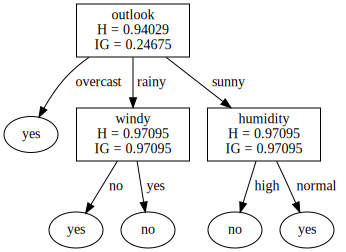

In [23]:
# It's just a visualization of the graph
# If it doesn't work, it doesn't matter
try:
    from IPython.display import SVG
    from graphviz        import Source
    from IPython.display import display
    
    graph = Source(id3_classifier.graphviz())
    display(SVG(graph.pipe(format='svg')))

except ImportError:
    print('You have to install graphviz: https://graphviz.org/download/')

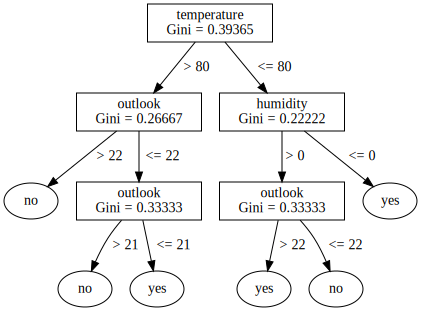

In [24]:
# It's just a visualization of the graph
# If it doesn't work, it doesn't matter
try:
    from IPython.display import SVG
    from graphviz        import Source
    from IPython.display import display
    
    graph = Source(cart_classifier.graphviz())
    display(SVG(graph.pipe(format='svg')))

except ImportError:
    print('You have to install graphviz: https://graphviz.org/download/')

## II. Application and Analysis

In this section, we will test different concepts by running an experiment, formulating a hypothesis and trying to justify it. 
We will use [Cars Data](https://www.kaggle.com/abineshkumark/carsdata) just for 3 classes: US., Euroupe. and Japan. 

In [25]:
# Dataset import
cars_data = pd.read_csv('data/cars.csv', skipinitialspace=True)
# Remove missing values
cars_data.dropna(inplace=True)
# Yay! We did it! These are the first samples
cars_data.head()

,mpg,cylinders,cubicinches,hp,weightlbs,time-to-60,year,brand
0,14.0,8,350.0,165,4209.0,12,1972,US.
1,31.9,4,89.0,71,1925.0,14,1980,Europe.
2,17.0,8,302.0,140,3449.0,11,1971,US.
3,15.0,8,400.0,150,3761.0,10,1971,US.
4,30.5,4,98.0,63,2051.0,17,1978,US.


In [26]:
cars_data.dtypes

mpg            float64
cylinders        int64
cubicinches    float64
hp               int64
weightlbs      float64
time-to-60       int64
year             int64
brand           object
dtype: object

In [27]:
X_cars = cars_data.values[:, :-1]
Y_cars = cars_data.values[:,  -1]

X_cars_train, X_cars_test, Y_cars_train, Y_cars_test = train_test_split(X_cars, 
                                                                        Y_cars, 
                                                                        test_size=0.2, 
                                                                        random_state=0) 

X_cars_train.shape, X_cars_test.shape

((204, 7), (52, 7))

### II.1. Decision trees and Random forests

We want to test the effect of different hyper-parameters of decision trees.


In Scikit-learn's implemtation (**DecisionTreeClassifier**), features are always randomly permuted at each split.
The tree will be undeterministic (which is good for overfitting, but not good for tessting the effect of hyper-parameters).
In this case, we stop this property using **random_state=0**.

#### II.1.1. Feature selection criteria

In scikit-learn, there is only CART which can use both: 
1. Entropy
1. Gini

Both will generate slightly different decision tree structures. We want to test the effect of the structure on training and test.

In [28]:
Xtrain = X_cars_train
Ytrain = Y_cars_train
Xtest  = X_cars_test
Ytest  = Y_cars_test
fnames = cars_data.columns


gini_stats         = []
entropy_stats      = []
gini_classifier    = DecisionTreeClassifier(criterion='gini'   , random_state=0, min_samples_leaf=7)
entropy_classifier = DecisionTreeClassifier(criterion='entropy', random_state=0, min_samples_leaf=7)

# ============ GINI ====================
# ................ Train ..............
temps_debut = timeit.default_timer()
gini_classifier.fit(Xtrain, Ytrain)
gini_stats.append(timeit.default_timer() - temps_debut)
# ........... Evaluation train .........
gini_stats.append(f1_score(Ytrain, gini_classifier.predict(Xtrain), average='micro'))
# ................ Test ................
temps_debut = timeit.default_timer()
Ychoix_pred = gini_classifier.predict(Xtest)
gini_stats.append(timeit.default_timer() - temps_debut)
# ........... Evaluation test ...........
gini_stats.append(f1_score(Ytest, Ychoix_pred, average='micro'))

# =========== Entropy ==================
# ............ Train ............
temps_debut = timeit.default_timer()
entropy_classifier.fit(Xtrain, Ytrain)
entropy_stats.append(timeit.default_timer() - temps_debut)
# ........... Evaluation train ........
entropy_stats.append(f1_score(Ytrain, entropy_classifier.predict(Xtrain), average='micro'))
# ................ Test ................
temps_debut = timeit.default_timer()
Ychoix_pred = entropy_classifier.predict(Xtest)
entropy_stats.append(timeit.default_timer() - temps_debut)
# ........... Evaluation test ...........
entropy_stats.append(f1_score(Ytest, Ychoix_pred, average='micro'))

print('Fin')

Fin


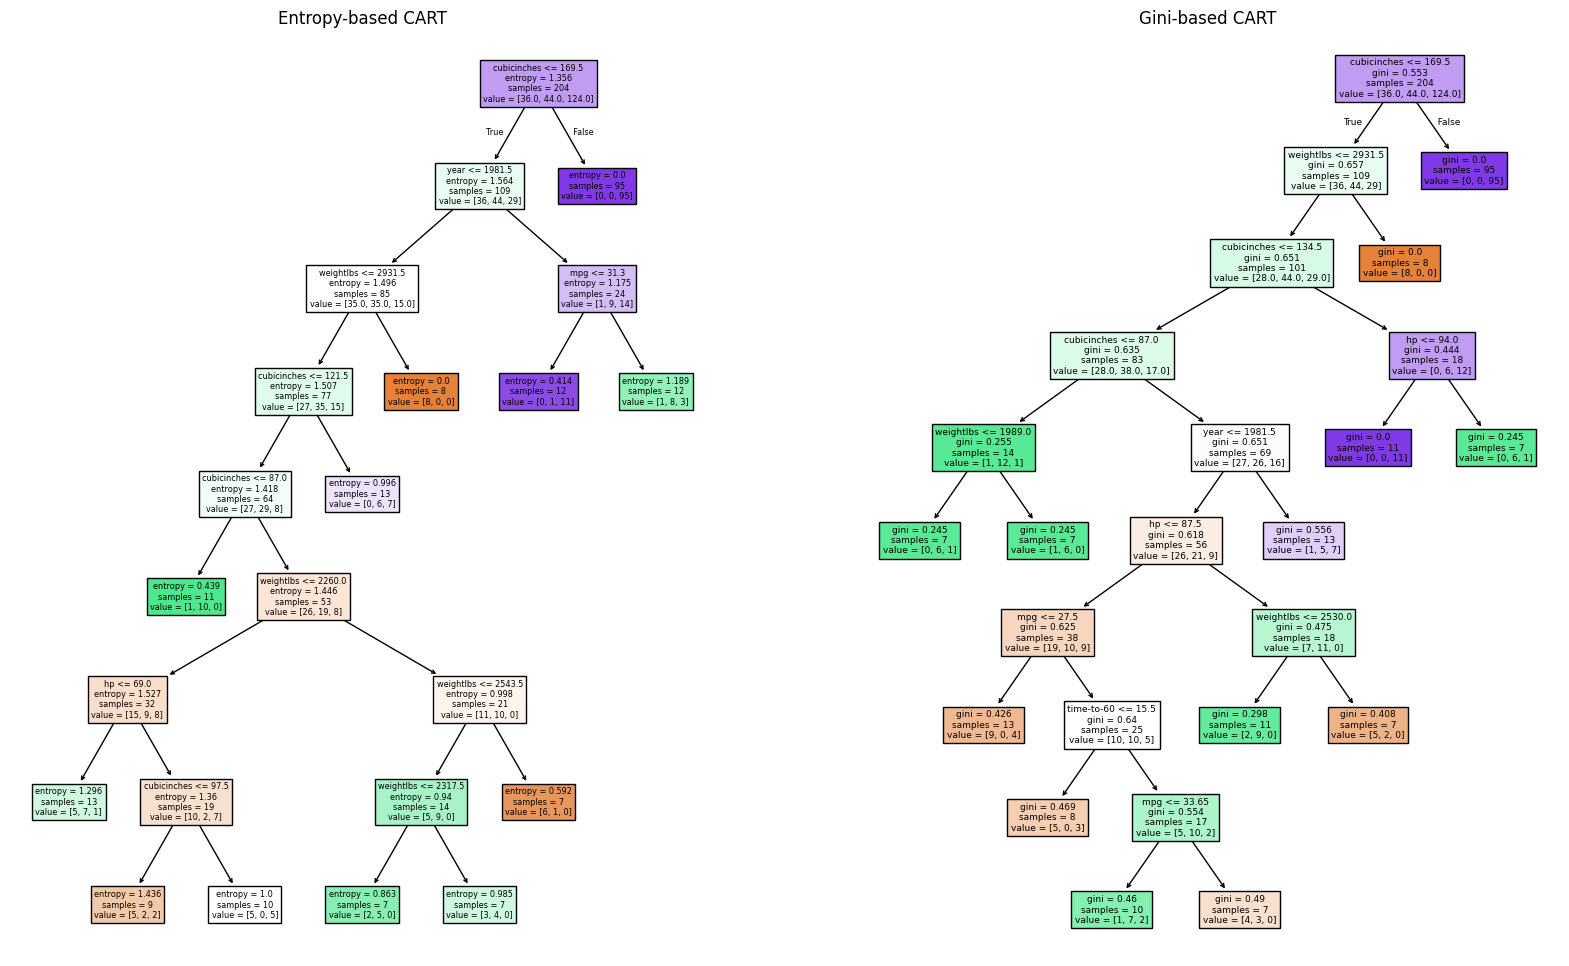

In [29]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figwidth (20)
fig.set_figheight(12)
tree.plot_tree(entropy_classifier, ax=ax1, feature_names=fnames, filled=True)
tree.plot_tree(gini_classifier   , ax=ax2, feature_names=fnames, filled=True)
ax1.set_title('Entropy-based CART')
ax2.set_title('Gini-based CART')
plt.show()

In [30]:
pd.DataFrame({
    'Criteria' : ['Train Time', 'Train F1', 'Test Time', 'Test F1'],
    'Entropy-based CART' : entropy_stats,
    'Gini-based CART'    : gini_stats
})

,Criteria,Entropy-based CART,Gini-based CART
0,Train Time,0.002418,0.003630
1,Train F1,0.838235,0.872549
2,Test Time,0.000487,0.000455
3,Test F1,0.788462,0.807692


**TODO: Analyze the results**

1. Compare the two trees' structures (depth, leafs number, position of leafs)
1. Justify the training time based on the algorithms and trees structures
1. Justify the test time based on the algorithms and trees structures

**Answers**

1. Comparaison : 
- Depth: both trees have nearly the same maximum depth , the Gini-based CART is one level deeper than the Entropy-based CART.
- Leaves: the Gini-based tree has slightly more leaves ( one leaf to be exact ).
- Leaf positions: the entropy tree has more early/shallow leaves, while the Gini tree is a bit more spread out.
1. The entropy-based CART trained faster (0.001409 vs 0.001972).That suggests the tree structure mattered more than the impurity formula. The entropy tree appears slightly more compact, so it likely required evaluating and creating fewer effective splits/nodes overall. Because the training process stops earlier in some branches, the total computation was lower, which explains the shorter training time.

1. Prediction time depends mainly on the number of decisions from root to leaf. Since the entropy tree is slightly smaller and more compact, samples reach leaves a bit faster on average, so its test time is lower .

#### II.1.2. Maximum depth

We want to test the effect of stopping creteria "maximum depth", so we used F1 score as classification quality measure.

For each maximum depth, we trained a decision/random forest tree and calculated its F1 score on training data (to test convergence) and on test data (to test generalization).

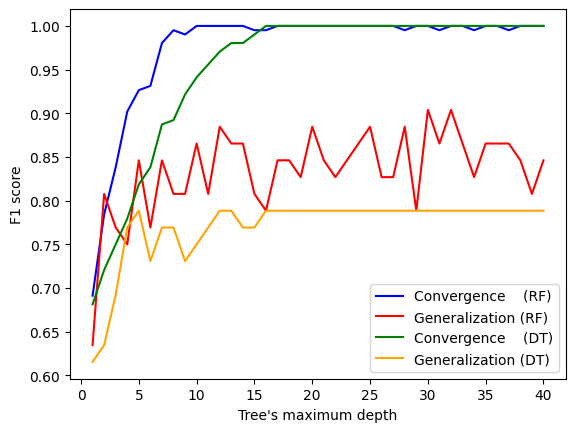

In [31]:
MAX_DEPTH     = 40
MAX_DEPTH_lst = range(1, MAX_DEPTH+1, 1)

f1_trn_md_DT  = []
f1_tst_md_DT  = []
f1_trn_md_RF  = []
f1_tst_md_RF  = []
for max_depth in MAX_DEPTH_lst:
    mdl_DT = DecisionTreeClassifier(random_state=0, max_depth=max_depth)
    mdl_DT.fit(X_cars_train, Y_cars_train)
    f1_trn_md_DT.append(f1_score(Y_cars_train, mdl_DT.predict(X_cars_train), average='micro'))
    f1_tst_md_DT.append(f1_score(Y_cars_test , mdl_DT.predict(X_cars_test) , average='micro'))

    mdl_RF = RandomForestClassifier(n_estimators=30, max_depth=max_depth)
    mdl_RF.fit(X_cars_train, Y_cars_train)
    f1_trn_md_RF.append(f1_score(Y_cars_train, mdl_RF.predict(X_cars_train), average='micro'))
    f1_tst_md_RF.append (f1_score(Y_cars_test , mdl_RF.predict(X_cars_test) , average='micro'))


plt.plot(MAX_DEPTH_lst, f1_trn_md_RF, color='blue'  , label='Convergence    (RF)')
plt.plot(MAX_DEPTH_lst, f1_tst_md_RF, color='red'   , label='Generalization (RF)')
plt.plot(MAX_DEPTH_lst, f1_trn_md_DT, color='green' , label='Convergence    (DT)')
plt.plot(MAX_DEPTH_lst, f1_tst_md_DT, color='orange', label='Generalization (DT)')
plt.ylabel('F1 score')
plt.xlabel('Tree\'s maximum depth')
plt.legend()
#plt.rcParams["figure.figsize"] = (3,7)
plt.show()

**TODO: Analyze the results**

1. Why F1 score (convergence) is not enhanced after depth=17 in decision trees (DT)?
1. Why F1 score (Generalization) is not enhanced after depth=17 in decision trees (DT)?
1. Why Random forests (RF) converge better then decision trees (DT) with less maximum depth? 
1. Why Random forests (RF) generalize better then decision trees (DT)? 

**Answers**

1. By depth 17, the tree has likely achieved total purity. This means every training sample has been assigned to a leaf node where 100% of the samples belong to the same class. Once the training error hits zero and the F1 score reaches $1.0$, there is no room for further "enhancement"
1. Flattens out. The rules the tree is creating at depth 17 are so hyper-specific to the training data that they do not apply to new data. In machine learning, we say the model has lost its ability to capture the underlying pattern and is instead capturing the "noise"
1. Random Forests converge faster because they combine diverse, shallower trees that each capture different data patterns. This ensemble approach maps total complexity more efficiently than a single tree, which would need excessive depth to achieve the same result alone.
1. Random Forests improve generalization by averaging multiple diverse trees to cancel out individual errors. This ensemble approach reduces variance and prevents the model from memorizing noise, making it more robust than a single and overfitted Decision tree.

#### II.1.3. Minimum leaf samples

We want to test the effect of stopping creteria "mimimum samples in leafs", so we used F1 score as classification quality measure.

For each minimum leaf samples number, we trained a decision tree/random forest and calculated its F1 score on training data (to test convergence) and on test data (to test generalization).

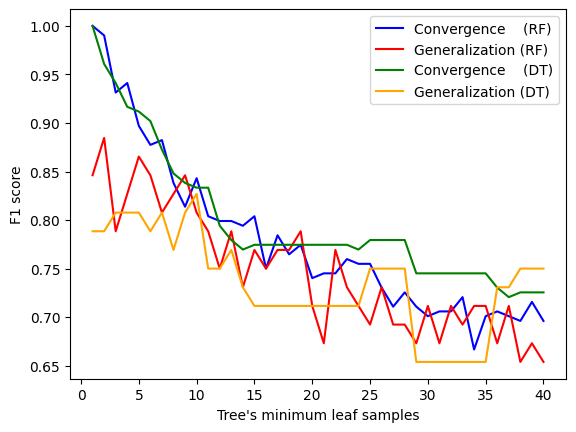

In [32]:
MIN_LEAF    = 40
MIN_LEAF_lst = range(1, MIN_LEAF+1, 1)

f1_trn_ml_DT = []
f1_tst_ml_DT = []
f1_trn_ml_RF = []
f1_tst_ml_RF = []
for min_samples_leaf in MIN_LEAF_lst:
    mdl_DT = DecisionTreeClassifier(random_state=0, min_samples_leaf=min_samples_leaf)
    mdl_DT.fit(X_cars_train, Y_cars_train)
    f1_trn_ml_DT.append(f1_score(Y_cars_train, mdl_DT.predict(X_cars_train), average='micro'))
    f1_tst_ml_DT.append(f1_score(Y_cars_test , mdl_DT.predict(X_cars_test) , average='micro'))

    mdl_RF = RandomForestClassifier(n_estimators=30, min_samples_leaf=min_samples_leaf)
    mdl_RF.fit(X_cars_train, Y_cars_train)
    f1_trn_ml_RF.append(f1_score(Y_cars_train, mdl_RF.predict(X_cars_train), average='micro'))
    f1_tst_ml_RF.append(f1_score(Y_cars_test , mdl_RF.predict(X_cars_test) , average='micro'))


plt.plot(MIN_LEAF_lst, f1_trn_ml_RF, color='blue'  , label='Convergence    (RF)')
plt.plot(MIN_LEAF_lst, f1_tst_ml_RF, color='red'   , label='Generalization (RF)')
plt.plot(MIN_LEAF_lst, f1_trn_ml_DT, color='green' , label='Convergence    (DT)')
plt.plot(MIN_LEAF_lst, f1_tst_ml_DT, color='orange', label='Generalization (DT)')
plt.ylabel('F1 score')
plt.xlabel('Tree\'s minimum leaf samples')
plt.legend()
#plt.rcParams["figure.figsize"] = (3,7)
plt.show()

**TODO: Analyze the results**
1. Why F1 score of decision trees (DT) gets worst when increasing the minimum leaf samples?
1. Why F1 score of decision trees (DT) gets better then random forests when increasing the minimum leaf samples?

**Answers**

1. Increasing minimum leaf samples makes the tree less complex.
The tree can no longer create small, specific leaves, so it captures less detail from the data.
This causes underfitting: the model becomes too simple and misses important patterns.
That is why both convergence and generalization F1 for DT tend to decrease as minimum leaf samples grows.
1. As minimum leaf samples increases, random forest trees become overly constrained in addition to already being randomized, so the ensemble underfits more than the single decision tree. This can make DT achieve a higher F1 than RF at large leaf sizes.


### II.2. Ensemle Learning

Random forests are just bagging over decision trees. 
We want to test different hyper-parameters of ensemble learning.

#### II.2.1. Estimators' number

We want to test the effect of estimators' number in both AdaBoost and Bagging. 
We applied these two ensemble learning techniques on decision trees and logistic regression.

In [38]:
MAX_ESTIMATORS     = 50
MAX_ESTIMATORS_lst = range(1, MAX_ESTIMATORS+1, 1)

mdls = [
    ('Logistic Regression', LogisticRegression(solver='liblinear')), 
    ('Decision Tree', DecisionTreeClassifier(random_state=0))
]

mdls_perf = {}
for mdl_name, mdl in mdls:
    mdls_perf[mdl_name] = {'bagging': [], 'boosting': []}

for n_estimators in MAX_ESTIMATORS_lst:
    for mdl_name, mdl in mdls:
        mdl_bagging  = BaggingClassifier (estimator=mdl, n_estimators=n_estimators)
        mdl_boosting = AdaBoostClassifier(estimator=mdl, n_estimators=n_estimators, algorithm='SAMME')

        mdl_bagging.fit(X_cars_train, Y_cars_train)
        Y_pred = mdl_bagging.predict(X_cars_test)
        mdls_perf[mdl_name]['bagging'].append(accuracy_score(Y_cars_test, Y_pred))


        mdl_boosting.fit(X_cars_train, Y_cars_train)
        Y_pred = mdl_boosting.predict(X_cars_test)
        mdls_perf[mdl_name]['boosting'].append(accuracy_score(Y_cars_test, Y_pred))

print('DONE')

TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'algorithm'

In [ ]:
fig, axs = plt.subplots(1, len(mdls), figsize=(16,5))

for i, (mdl_name, mdl) in enumerate(mdls):
    axs[i].plot(MAX_ESTIMATORS_lst, mdls_perf[mdl_name]['bagging' ], label='Bagging  ' + mdl_name)
    axs[i].plot(MAX_ESTIMATORS_lst, mdls_perf[mdl_name]['boosting'], label='Boosting ' + mdl_name)

    axs[i].set_ylabel('Accuracy')
    axs[i].set_xlabel('Number of estimators')
    axs[i].set_title(mdl_name)
    axs[i].legend()


# plt.ylabel('Accuracy')
# plt.xlabel('Number of estimators')
# plt.legend()
#plt.rcParams["figure.figsize"] = (3,7)
plt.show()

NameError: name 'plt' is not defined

**TODO: Analyze the results**
1. Why Bagging is better than boosting in this experiment (according to the data)?
1. Propose a logical hypothesis to why Logistic Regression does not improve using boosting.
1. Why bagging is enhancing accuracy using decision trees?
1. Why boosting is not enhancing accuracy as much as bagging using decision trees?

**Answers**

1. bagging works better here because it benefits from combining multiple models trained on different bootstrap samples, especially for decision trees, which are unstable learners. Boosting, on the other hand, seems to bring little extra benefit in this experiment, since its accuracy remains lower or nearly unchanged.
1. Boosting  helps when weak learners can be sequentially corrected.But logistic regression is already a stable linear model, so reweighting hard samples does not add much new capacity.
1. Decision trees have high variance ie small changes in data can produce very different trees. Bagging trains many trees on different bootstrap samples and averages them. This reduces variance and makes predictions more stable. 
1. Boosting focuses on previously misclassified samples, which can make trees chase noise or outliers.
Decision trees are already flexible, so boosting may overfit more easily.
Bagging is better suited here because it stabilizes trees instead of forcing them to focus repeatedly on hard cases.

#### II.2.2. Bootstrap's size

In this expreiment, we are interested in bagging; more precisely, Bootstrap's size.

*P.S. We used SGD instead of linear logistic regression because this latter has some problems with bagging*

In [ ]:
BAG_PERC_lst = np.arange(0.1, 1, 0.01)

mdls_bag = [
    ('Logistic Regression', SGDClassifier()),
    # ('Logistic Regression', LogisticRegression(solver='liblinear')), 
    ('Decision Tree', DecisionTreeClassifier(random_state=0))
]

mdls_bag_perf = {}
for mdl_name, mdl in mdls_bag:
    mdls_bag_perf[mdl_name] = {'train': [], 'test': []}

for max_samples in BAG_PERC_lst:
    for mdl_name, mdl in mdls_bag:
        mdl_bagging  = BaggingClassifier (estimator=mdl, n_estimators=20, max_samples=max_samples)

        mdl_bagging.fit(X_cars_train, Y_cars_train)
        Y_pred = mdl_bagging.predict(X_cars_train)
        mdls_bag_perf[mdl_name]['train'].append(accuracy_score(Y_cars_train, Y_pred))

        Y_pred = mdl_bagging.predict(X_cars_test)
        mdls_bag_perf[mdl_name]['test'].append(accuracy_score(Y_cars_test, Y_pred))

print('DONE')

NameError: name 'np' is not defined

In [ ]:
fig, axs = plt.subplots(1, len(mdls_bag), figsize=(16,5))

for i, (mdl_name, mdl) in enumerate(mdls_bag):
    axs[i].plot(BAG_PERC_lst, mdls_bag_perf[mdl_name]['train' ], label='Train  ' + mdl_name)
    axs[i].plot(BAG_PERC_lst, mdls_bag_perf[mdl_name]['test']  , label='Test '   + mdl_name)

    axs[i].set_ylabel('Accuracy')
    axs[i].set_xlabel('Percentage of bootstrap')
    axs[i].set_title(mdl_name)
    axs[i].legend()


# plt.ylabel('Accuracy')
# plt.xlabel('Number of estimators')
# plt.legend()
#plt.rcParams["figure.figsize"] = (3,7)
plt.show()

**TODO: Analyze the results**
1. Why the accuracy's cruve is not smooth?
1. Why increasing the size of a bootstrap increases the accuracy in case of decision trees?
1. Why it does not in case of logistic regression?

**Answers**

1. The curves are jagged because each point represents a new random sample; small changes in the bootstrap can include or exclude outliers, causing the model to learn differently. This noise is amplified by the high variance of Decision Trees and the randomness of SGD, which are both highly sensitive to minor data fluctuations.
1. Larger bootstraps provide more representative data, allowing trees to capture real patterns rather than noise. This improves accuracy because Decision trees are high-variance models; small samples cause them to overfit to local anomalies, whereas larger samples enable more robust splits that generalize better to unseen data.
1. Logistic Regression is a low-variance model that remains stable once its linear boundary is set. Because it is limited by its **linear structure**, adding more data cannot overcome its inability to capture non-linear patterns, causing the accuracy to plateau early.

In [39]:
print('Trees and forests are crucial for life on earth')
print('Not these trees though :)')

Trees and forests are crucial for life on earth
Not these trees though :)
